Let's start by importing the necessary libraries. We'll use requests for API calls, pandas for convenient data viewing, and BeautifulSoup for HTML parsing.


In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import json

print("Libraries imported successfully.")

Libraries imported successfully.


It's good practice to define our API endpoints as constants. This makes the code cleaner and easier to maintain.

In [2]:
BASE_URL = "https://apicr.minzdrav.gov.ru/api.ashx"
LIST_RECS_URL = f"{BASE_URL}?op=GetJsonClinrecs"
DETAIL_REC_URL_TEMPLATE = f"{BASE_URL}?op=GetClinrec2&id={{id}}"

print(f"List URL: {LIST_RECS_URL}")

List URL: https://apicr.minzdrav.gov.ru/api.ashx?op=GetJsonClinrecs


Now, let's make our first API call to get the list of all available recommendations. We'll include basic error handling.

In [3]:
try:
    response = requests.get(LIST_RECS_URL)
    response.raise_for_status()  # This will raise an HTTPError if the HTTP request returned an unsuccessful status code
    all_recs = response.json()
    print(f"Successfully fetched {len(all_recs)} recommendations.")
except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")
    all_recs = []

Successfully fetched 615 recommendations.


The best way to understand a list of objects is to load it into a pandas DataFrame.

In [4]:
if all_recs:
    df_recs = pd.DataFrame(all_recs)
    print("Top 5 recommendations:")
    display(df_recs.head())
else:
    print("No recommendations to display.")

Top 5 recommendations:


,id,status,db_id,code,version,ver,age,name,Mkb,ass,publish_date,NPC_approved,apply_status,prev_cr_id
0,574_1,0,719,574,1,1,1,Рак желудка,[C16],"Ассоциация онкологов России, Общероссийская об...",/Date(1586379600000)/,True,Применяется,None
1,569_1,0,812,569,1,1,3,Желудочковые нарушения ритма. Желудочковые тах...,"[I47.0, I47.2, I49, I46, I46.0, I46.1, I46.9, ...",Общероссийская общественная организация «Росси...,/Date(1605128400000)/,True,Применяется,None
2,80_1,0,833,80,1,1,1,Трофобластические опухоли,[C58],"Ассоциация онкологов России, Общероссийская об...",/Date(1583096400000)/,True,Применяется,None
3,600_2,0,1030,600,2,2,1,Падения у пациентов пожилого и старческого воз...,"[W00, W08, W10, W11, W17, W19, R29.6, W01, W02...","Общественная организация ""Российская ассоциаци...",/Date(1604523600000)/,True,Применяется,None
4,616_1,0,1033,616,1,2,1,Хроническая боль у пациентов пожилого и старче...,"[R52.1, R52.2, R52.9, M25.5, M54.5, M54, R10.2]",Общероссийская общественная организация «Росси...,/Date(1604523600000)/,True,Применяется,None


Our goal is to focus on pediatrics (age: 2 or age: 3) and approved (NPC_approved: true) recommendations. Let's create a filtered DataFrame.

In [5]:
if not df_recs.empty:
    # Age category 2 is 'children', 3 is 'adults and children'
    # We also want only those approved by the Scientific and Practical Council (NPC_approved)
    filtered_df = df_recs[
        (df_recs["age"].isin([2, 3])) & (df_recs["NPC_approved"] == True)
    ].copy()

    print(f"Found {len(filtered_df)} relevant pediatric recommendations.")
    display(filtered_df.head())
else:
    print("DataFrame is empty, skipping filtering.")

Found 363 relevant pediatric recommendations.


,id,status,db_id,code,version,ver,age,name,Mkb,ass,publish_date,NPC_approved,apply_status,prev_cr_id
1,569_1,0,812,569,1,1,3,Желудочковые нарушения ритма. Желудочковые тах...,"[I47.0, I47.2, I49, I46, I46.0, I46.1, I46.9, ...",Общероссийская общественная организация «Росси...,/Date(1605128400000)/,True,Применяется,None
8,474_2,0,1138,474,2,2,3,"Врожденные аномалии костей черепа и лица, врож...","[Q75.0, Q67.2, Q67.3, Q75.3, Q75.1, Q75.4, Q87...",ООО «Общество специалистов в области челюстно-...,/Date(1624356072343)/,True,Применяется,None
10,372_2,0,1228,372,2,2,3,Кистозный фиброз (муковисцидоз),[E84],"Союз педиатров России, Ассоциация медицинских ...",/Date(1630655337147)/,True,Применяется,None
12,485_2,0,1309,485,2,2,2,Аскаридоз у детей,"[B77, B77.0, B77.8, B77.9]","Международная общественная организация ""Евро-А...",/Date(1639067019057)/,True,Применяется,None
13,466_2,0,1325,466,2,2,2,Гемолитико-уремический синдром,[D59.3],"Союз педиатров России, Столичная ассоциация вр...",/Date(1642453200000)/,True,Применяется,None


Our goal is to focus on pediatrics (age: 2 or age: 3) and approved (NPC_approved: true) recommendations. Let's create a filtered DataFrame.

In [6]:
if not df_recs.empty:
    # Age category 2 is 'children', 3 is 'adults and children'
    # We also want only those approved by the Scientific and Practical Council (NPC_approved)
    filtered_df = df_recs[
        (df_recs["age"].isin([2, 3])) & (df_recs["NPC_approved"] == True)
    ].copy()

    print(f"Found {len(filtered_df)} relevant pediatric recommendations.")
    display(filtered_df.head())
else:
    print("DataFrame is empty, skipping filtering.")

Found 363 relevant pediatric recommendations.


,id,status,db_id,code,version,ver,age,name,Mkb,ass,publish_date,NPC_approved,apply_status,prev_cr_id
1,569_1,0,812,569,1,1,3,Желудочковые нарушения ритма. Желудочковые тах...,"[I47.0, I47.2, I49, I46, I46.0, I46.1, I46.9, ...",Общероссийская общественная организация «Росси...,/Date(1605128400000)/,True,Применяется,None
8,474_2,0,1138,474,2,2,3,"Врожденные аномалии костей черепа и лица, врож...","[Q75.0, Q67.2, Q67.3, Q75.3, Q75.1, Q75.4, Q87...",ООО «Общество специалистов в области челюстно-...,/Date(1624356072343)/,True,Применяется,None
10,372_2,0,1228,372,2,2,3,Кистозный фиброз (муковисцидоз),[E84],"Союз педиатров России, Ассоциация медицинских ...",/Date(1630655337147)/,True,Применяется,None
12,485_2,0,1309,485,2,2,2,Аскаридоз у детей,"[B77, B77.0, B77.8, B77.9]","Международная общественная организация ""Евро-А...",/Date(1639067019057)/,True,Применяется,None
13,466_2,0,1325,466,2,2,2,Гемолитико-уремический синдром,[D59.3],"Союз педиатров России, Столичная ассоциация вр...",/Date(1642453200000)/,True,Применяется,None


Let's pick one recommendation from our filtered list to develop our parsing logic.

In [7]:
if not filtered_df.empty:
    sample_rec = filtered_df.iloc[0]
    sample_id = sample_rec["id"]
    print("Selected sample for detailed analysis:")
    print(f"ID: {sample_id}")
    print(f"Name: {sample_rec['name']}")
else:
    print("No sample to select.")
    sample_id = None

Selected sample for detailed analysis:
ID: 569_1
Name: Желудочковые нарушения ритма. Желудочковые тахикардии и внезапная сердечная смерть


Using the id from our sample, we'll now call the detailed endpoint.

In [9]:
if sample_id:
    detail_url = DETAIL_REC_URL_TEMPLATE.format(id=sample_id)
    try:
        response = requests.get(detail_url)
        response.raise_for_status()
        detailed_rec = response.json()
        print("Successfully fetched detailed recommendation.")
        # We can pretty-print the json to explore its structure
        # print(json.dumps(detailed_rec, indent=2, ensure_ascii=False))
    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        detailed_rec = {}
else:
    print("No sample ID to fetch details for.")

Successfully fetched detailed recommendation.


This is the core of our transformation logic. We need to extract clean text from the HTML content found in obj['sections']. Let's test it on the first section.


--- ORIGINAL HTML ---
<div>&nbsp;</div>
<p>&nbsp;</p>
<table cellspacing="0" cellpadding="0" align="left">
<tbody>
<tr>
<td width="0" height="0">&nbsp;</td>
<td width="267">&nbsp;</td>
<td width="138">&nbsp;</td>
<td width="18">&nbsp;</td>
<td width="161">&nbsp;</td>
<td width="32">&nbsp;</td>
<td width="138">&nbsp;</td>
</tr>
<tr>
<td height="108">&nbsp;</td>
<td>&nbsp;</td>
<td colspan="2" align="left" valign="top"></td>
</tr>
<tr>
<td height="134">&nbsp;</td>
</tr>
<tr>
<td height="275">&nbsp;</td>
<td colspan="4" align="left" valign="top"><img width="584" height="275" data-textbox-image="2" /></td>
</tr>
<tr>
<td height="28">&nbsp;</td>
</tr>
<tr>
<td height="142">&nbsp;</td>
<td colspan="5" bgcolor="white" width="616" height="142">
<table width="100%" cellspacing="0" cellpadding="0">
<tbody>
<tr>
<td>
<div>
<p>Профессиональные ассоциации:</p>
<p><strong>&nbsp;</strong></p>
<ul>
<li>Ассоциация детских кардиологов России</li>
<li>Союз педиатров России</li>
</ul>
<p><strong>&nbsp;</s
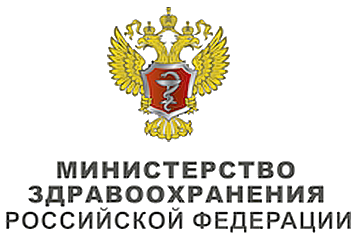
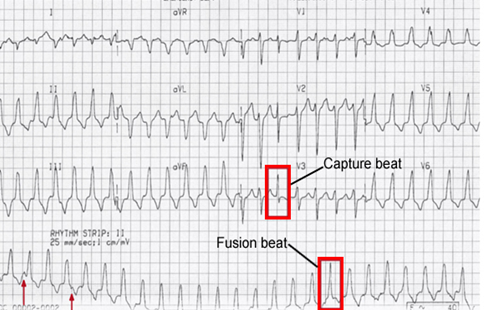
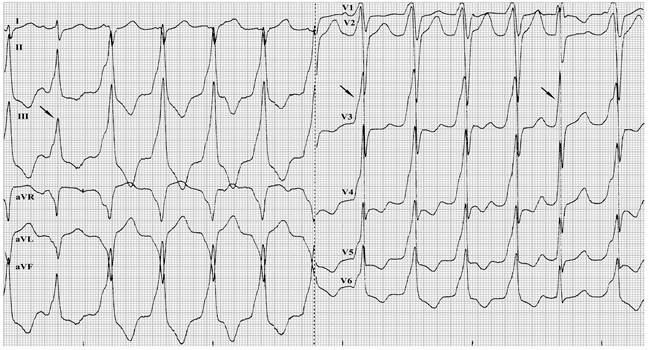
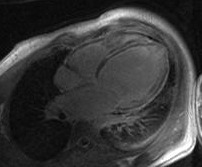
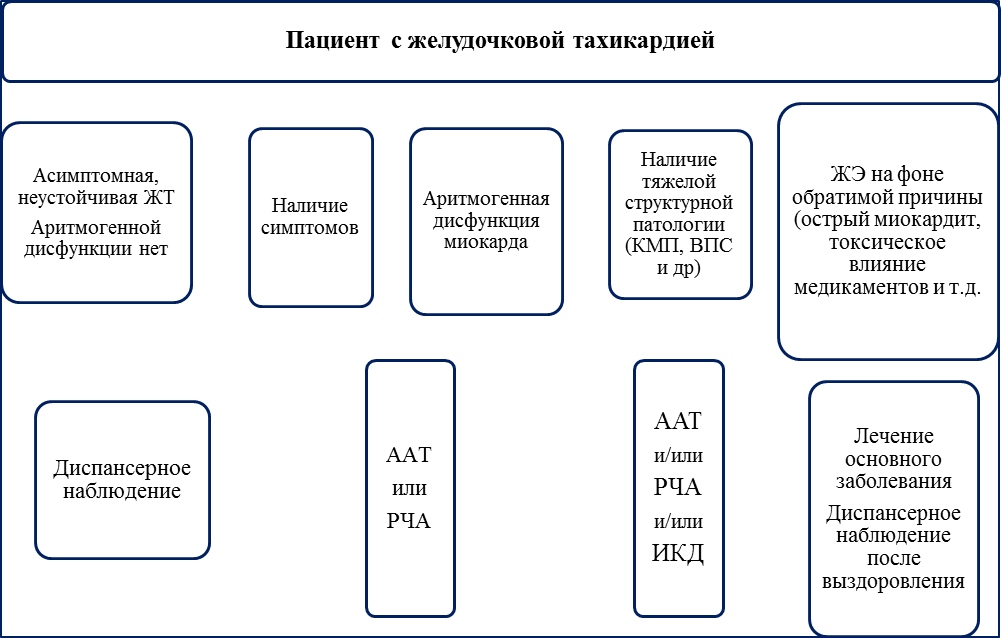

In [10]:
if detailed_rec and "obj" in detailed_rec and "sections" in detailed_rec["obj"]:
    first_section = detailed_rec["obj"]["sections"][0]
    html_content = first_section.get("content", "")

    # Use BeautifulSoup to parse the HTML
    soup = BeautifulSoup(html_content, "html.parser")

    # Extract text. separator='\n' helps maintain paragraph structure.
    clean_text = soup.get_text(separator="\n", strip=True)

    print("--- ORIGINAL HTML ---")
    print(html_content)
    print("\n--- CLEANED TEXT ---")
    print(clean_text)
else:
    print("Could not find sections in the detailed recommendation.")

Now, let's turn our prototype logic into a function that processes the entire document and formats it as Markdown. This function will be the blueprint for our etl/parser.py module.

In [11]:
def parse_rec_to_markdown(rec_json: dict) -> str:
    """
    Parses a detailed clinical recommendation JSON object into a clean Markdown string.
    """
    if not rec_json:
        return ""

    # Main title from the root of the object
    main_title = rec_json.get("name", "Untitled Recommendation")
    markdown_content = f"# {main_title}\n\n"

    sections = rec_json.get("obj", {}).get("sections", [])
    if not sections:
        return markdown_content  # Return just the title if no content

    for section in sections:
        section_title = section.get("title", "Untitled Section")
        html_content = section.get("content", "")

        # Add section title
        markdown_content += f"## {section_title}\n\n"

        # Parse and add cleaned content
        if html_content:
            soup = BeautifulSoup(html_content, "html.parser")
            clean_text = soup.get_text(separator="\n", strip=True)
            markdown_content += f"{clean_text}\n\n"

    return markdown_content


if "detailed_rec" in locals() and detailed_rec:
    full_markdown_content = parse_rec_to_markdown(detailed_rec)
    print("--- FULL PARSED MARKDOWN (first 1000 chars) ---")
    print(full_markdown_content[:1000])
else:
    print("No detailed_rec available to parse.")

--- FULL PARSED MARKDOWN (first 1000 chars) ---
# Желудочковые нарушения ритма. Желудочковые тахикардии и внезапная сердечная смерть

## Исходный документ

Профессиональные ассоциации:
Ассоциация детских кардиологов России
Союз педиатров России
Согласованы
Научным советом Министерства Здравоохранения Российской Федерации
__ __________201_ г.
Утверждены
Союзом педиатров России
Ассоциацией детских кардиологов России
­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­
Оглавление
Ключевые слова. 3
Список сокращений. 4
Термины и определения. 5
1. Краткая информация. 6
1.1 Определение. 6
1.2 Этиология и патогенез. 7
1.3 Эпидемиология. 9
1.4 Кодирование по МКБ-10. 9
1.5 Примеры диагнозов. 9
1.6 Классификация. 9
2. Диагностика. 10
2.1 Жалобы и анамнез. 11
2.2 Физикальное обследование. 12
2.3 Лабораторная диагностика. 12
2.4 Инструментальная диагностика. 13
2.4 Иная диагностика. 17
2.5 Дифференциальная диагностика. 17
3. Лечение. 18
3.1 Консервативное лечение. 18
3.2 Хирургическое лечение. 2

We have successfully:
Connected to the API and fetched the list of recommendations.
Filtered the data to get relevant documents.
Prototyped a robust parser to convert the HTML content into clean, structured Markdown.
The logic we've developed in this notebook is now ready to be refactored and moved into our etl/ directory as Python modules (downloader.py, parser.py). We've laid a solid foundation for our automated ETL pipeline.